In [1]:
using Pyehtim
plt = pyimport("matplotlib.pyplot")

/home/amandeep-kaur/Downloads/eht-imaging-1.2.10/.CondaPkg/.pixi/envs/default/lib/python3.10/site-packages/ehtim/__init__.py:58: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Python: <module 'matplotlib.pyplot' from '/home/amandeep-kaur/Downloads/eht-imaging-1.2.10/.CondaPkg/.pixi/envs/default/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [31]:
using PythonCall
builtins = pyimport("builtins")

Python: <module 'builtins' (built-in)>

In [2]:
im = Pyehtim.ehtim.image.load_txt("/home/amandeep-kaur/aspire-black-hole-project/Data_files/img_ehtim200.dat")

Python: <ehtim.image.Image object at 0x7dda04315330>

In [3]:

eht = Pyehtim.ehtim.array.load_txt("/home/amandeep-kaur/aspire-black-hole-project/Data_files/EHT2017_m87.txt")

Python: <ehtim.array.Array object at 0x7dd9ac5476a0>

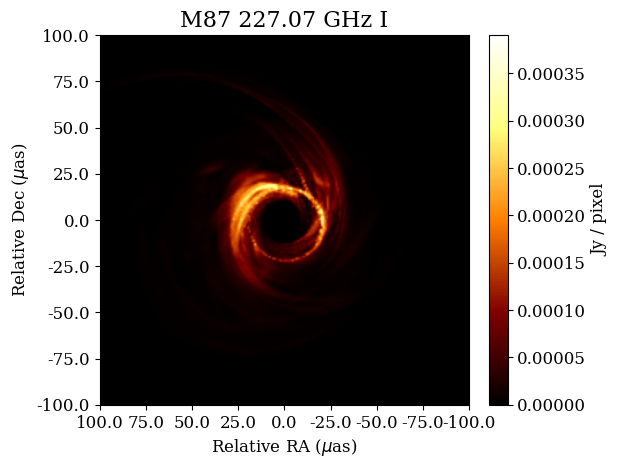

In [32]:
im.display()

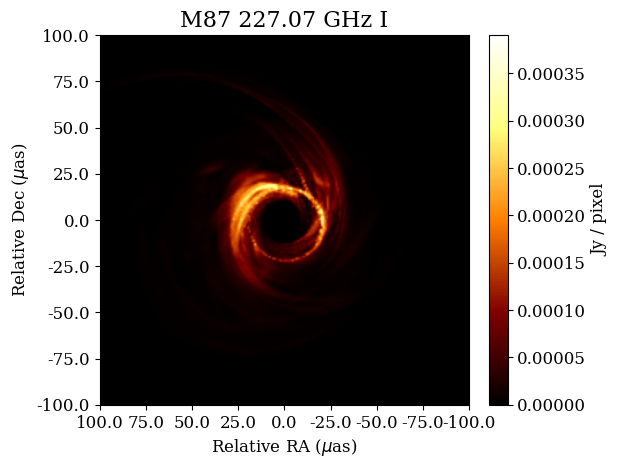

In [ ]:
# Adopted from ehtim tutorial on github
# Regrid image to have a smaller FOV and fewer pixels.
# im = im.regrid_image(
    # targetfov=200 * Pyehtim.ehtim.RADPERUAS,
    # npix=256)

# Display image.
# im.display()

In [6]:
target_flux=0.61
current_flux = im.total_flux()
scale_factor = target_flux / current_flux
im.imvec *= scale_factor
zbl = im.total_flux() # total flux
println(zbl)

0.61


Simulating observations using self defined parameters using im.observe

In [7]:
# simulation parameters
tint_sec = 30  # Integration time in seconds, 
tadv_sec = 300 # Advance time between scans
tstart_hr = 0  # GMST time of the start of the observation
tstop_hr = 24  # GMST time of the end of the observation
bw_hz = 2.e9   # Bandwidth in Hz

# generate the observation
obs = im.observe(eht, ttype = "fast", tint_sec, tadv_sec, tstart_hr, tstop_hr, bw_hz, add_th_noise = true,
                 sgrscat=false, ampcal=true, phasecal=true)


Python: <ehtim.obsdata.Obsdata object at 0x7dd9abe49060>

Plots

In [ ]:
# uv coverage
 obs.plotall("u","v", conj=true)
 plt.savefig("uv coverage")

# Plot amplitude with baseline u-v distance.
  obs.plotall("uvdist","amp")
  plt.savefig("amp vs baseline")

# Plot phase with baseline distance.
  obs.plotall("uvdist","phase")
  plt.savefig("phase vs baseline")

Simulate an observation based on real M87 data

In [8]:
# loading M87 observation
obs_M87_orig = Pyehtim.ehtim.obsdata.load_uvfits("/home/amandeep-kaur/Downloads/eht_imaging_tutorial-main/SR1_M87_2017_095_lo_hops_netcal_StokesI.uvfits")

# We have to change the image coordinates (ra, dec) and frequency (rf)
# to match the observed coordinates and frequency.
im_M87 = im.copy()
im_M87.ra = obs_M87_orig.ra
im_M87.dec = obs_M87_orig.dec
im_M87.rf = obs_M87_orig.rf

Python: 227070703125.0

In [29]:
# Simulate an observation with the samee settings as those of the 
# M87 observation( assuming calibrated amplitudes and phases)
obs_M87_calib = im_M87.observe_same(
    obs_M87_orig,
    add_th_noise=true,
    phasecal=true,
    ampcal=true,
    ttype="fast")

Python: <ehtim.obsdata.Obsdata object at 0x7dd9abe48970>

In [30]:
# uv coverage for this simulation
 obs_M87_calib.plotall("u","v", conj=true)
 plt.savefig("uv_calib coverage")

Python: None

Simulating more realistic M87-based observation

In [34]:
# Add scan info to Obsdata object so that per-scan stabilization and averaging
# can be done.
obs_M87_orig.add_scans()


# Std. dev. of the constant absolute gain of each telescope from a gain of 1:
gain_offset = builtins.dict([
    ("AA", 0.1),
    ("AP", 0.1),
    ("AZ", 0.1),
    ("LM", 0.6),
    ("PV", 0.1),
    ("SM", 0.1),
    ("JC", 0.1),
    ("SP", 0.1),
    ("SR", 0.0)
])
# Std. dev. of the time-varying gain differences:
gainp = builtins.dict([
    ("AA", 0.05),
    ("AP", 0.05),
    ("AZ", 0.05),
    ("LM", 0.5),
    ("PV", 0.05),
    ("SM", 0.05),
    ("JC", 0.05),
    ("SP", 0.15),
    ("SR", 0.0)
])

Python: {'AA': 0.05, 'AP': 0.05, 'AZ': 0.05, 'LM': 0.5, 'PV': 0.05, 'SM': 0.05, 'JC': 0.05, 'SP': 0.15, 'SR': 0.0}

In [35]:
# Simulate an observation with phase and amplitude (gain) errors.
obs_M87 = im_M87.observe_same(
    obs_M87_orig,
    add_th_noise=true,
    phasecal=false,
    ampcal=false,
    stabilize_scan_phase=true,  # `True` makes phase error constant per scan
    stabilize_scan_amp=true,    # `True` makes gain error constant per scan
    gain_offset=gain_offset,    # use station-dependent median gain error
    gainp=gainp,                # use station-dependent variability
    ttype="fast")

Python: <ehtim.obsdata.Obsdata object at 0x7dd9ab2eeb30>

In [37]:

# Compare phases with vs. without atmospheric noise.
Pyehtim.ehtim.plotting.comp_plots.plotall_obs_compare(
  [obs_M87_calib, obs_M87], "uvdist", "phase", ebar=false,
  legendlabels=["calibrated", "realistic"]);
  plt.savefig("phase comparisons")   

Python: None

Imaging

In [39]:
# Nominal resolution
res = obs_M87.res()
a= Pyehtim.ehtim.RADPERUAS
resolution= res/a
println("nominal resolution= $resolution muas")

nominal resolution= 24.965633535341087 muas


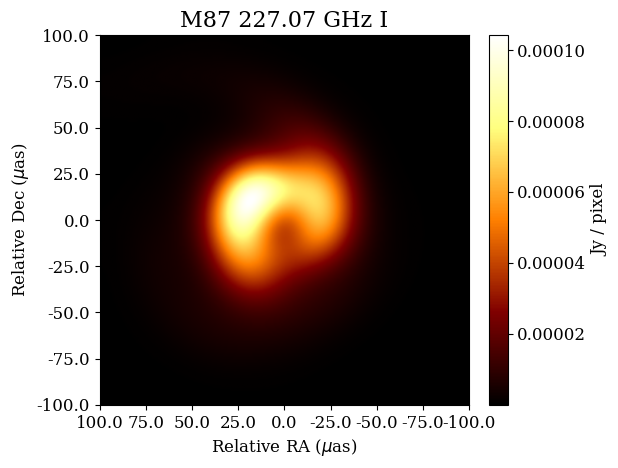

In [40]:
# Show the true image blurred to the nominal resolution.
blurry_im = im_M87.blur_circ(res)
blurry_im.display()

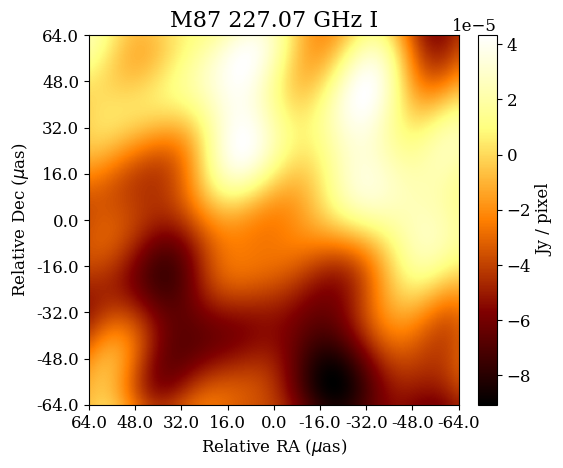

In [41]:
# dirty image
dim = obs_M87.dirtyimage(npix, fov)
dim.display()

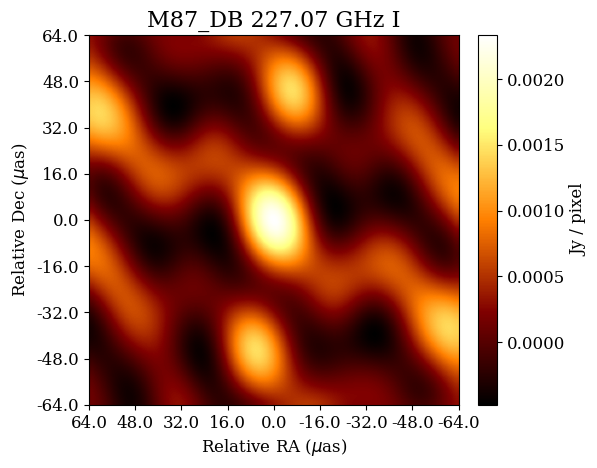

In [42]:
# dirty beam
dbeam = obs_M87.dirtybeam(npix, fov)
dbeam.display()

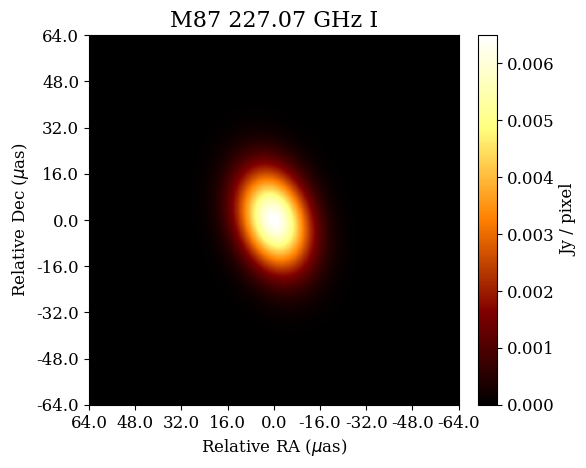

In [43]:
# clean beam
cbeam = obs_M87.cleanbeam(npix,fov)
cbeam.display()

Scan average observation data

In [44]:
# Make sure Obsdata objects have scan info.
obs_M87_calib.add_scans()

# Reduce each scan down to one average measurement.
obs_M87_calib_scan_avg = obs_M87_calib.avg_coherent(0, scan_avg=true)
obs_M87_scan_avg = obs_M87.avg_coherent(0, scan_avg=true)

Python: <ehtim.obsdata.Obsdata object at 0x7dd9a9398ac0>

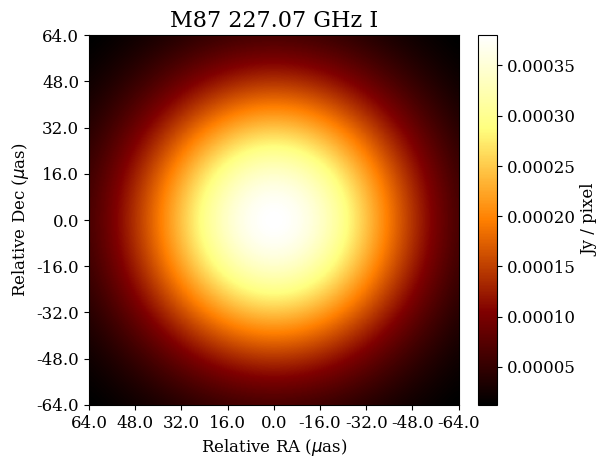

In [46]:
# prior image
gauss_fwhm = 80 * Pyehtim.ehtim.RADPERUAS
emptyim = Pyehtim.ehtim.image.make_square(obs_M87, npix, fov)
gaussim = emptyim.add_gauss(zbl, (gauss_fwhm, gauss_fwhm, 0, 0, 0))
# Make the initial image have the correct coordinates and reference frequency.
gaussim.source = "M87"
gaussim.ra = obs_M87.ra
gaussim.dec = obs_M87.dec
gaussim.rf = obs_M87.rf
gaussim.display()

Imaging from calibrated observation

In [ ]:
# Imaging from calibrated observations
# We can use just the complex visibilities because they are well-calibrated.
data_term = data_term = Dict("vis" => 1)
# We don't need strong regularization because the complex visibilities are
# already well constraining.
reg_term = Dict("tv2" => 0.1)

# Set up imager.
imgr = Pyehtim.ehtim.imager.Imager(
  obs_M87_calib_scan_avg, gaussim,
  prior_im=gaussim,
  flux=zbl,
  data_term=data_term,
  reg_term=reg_term,
  norm_reg=true,
  maxit=300,
  ttype="fast")

Python: <ehtim.imager.Imager object at 0x7dd9ab2eca60>

In [48]:
# Imaging round 1:
imgr.make_image_I(show_updates=true)
out1 = imgr.out_last()

Welcome to eht-imaging! v 1.2.10 

Loading text image:  /home/amandeep-kaur/aspire-black-hole-project/Data_files/img_ehtim200.dat
Generating empty observation file . . . 
Producing clean visibilities from image with fast FT . . . 
Adding gain + phase errors to data and applying a priori calibration . . . 
Adding thermal noise to data . . . 
Loading uvfits:  /home/amandeep-kaur/Downloads/eht_imaging_tutorial-main/SR1_M87_2017_095_lo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Loading uvfits:  /home/amandeep-kaur/Downloads/eht_imaging_tutorial-main/SR1_M87_2017_095_lo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Producing clean visibilities from image with fast FT . . . 
Adding gain + phase errors to data and applying a priori calibration . . . 
   Applying gain corruption: ampcal-->False
   Applying atmospher

Python: <ehtim.image.Image object at 0x7dd9a7270c70>

In [49]:
# Imaging round 2:
imgr.init_next = imgr.out_last().blur_circ(res)
imgr.make_image_I(show_updates=true)
out2 = imgr.out_last()

------------------------------------------------------------------
 173 | chi2_vis : 1.18 
        vis : 1.2 
        tv2 : 0.2 
------------------------------------------------------------------
 174 | chi2_vis : 1.18 
        vis : 1.2 
        tv2 : 0.2 
------------------------------------------------------------------
 175 | chi2_vis : 1.18 
        vis : 1.2 
        tv2 : 0.2 
------------------------------------------------------------------
 176 | chi2_vis : 1.17 
        vis : 1.2 
        tv2 : 0.2 
------------------------------------------------------------------
 177 | chi2_vis : 1.17 
        vis : 1.2 
        tv2 : 0.2 
------------------------------------------------------------------
 178 | chi2_vis : 1.17 
        vis : 1.2 
        tv2 : 0.2 
------------------------------------------------------------------
 179 | chi2_vis : 1.16 
        vis : 1.2 
        tv2 : 0.2 
------------------------------------------------------------------
 180 | chi2_vis : 1.16 
      

Python: <ehtim.image.Image object at 0x7dd9a7111270>

In [53]:
# Show the results of the imaging rounds.
outs = [out1, out2]
fig, axs = plt.subplots(1, length(outs), figsize=(5 * length(outs), 3.5))
for (i, out) in enumerate(outs)
  ax = axs[i-1]
  mappable = ax.imshow(out.ivec.reshape(npix, npix), cmap="afmhot")
  fig.colorbar(mappable, ax=ax)
  ax.axis("off")
  ax.set_title("Round $(i)")
end
plt.savefig("calibrated final plots")

Python: None

Imaging from realistic M87-based observation

In [55]:
# Inflate amplitude error bars with systematic noise, which accounts for
# gain errors, polarization leakage, etc.

# The following systematic noise estimates are taken from the fiducial
# eht-imaging pipeline.
systematic_noise = builtins.dict([
    ("AA", 0.01220),
    ("AP", 0.01339),
    ("AZ", 0.00860),
    ("LM", 0.17613),  # LMT had the most variability
    ("PV", 0.01220),
    ("SM", 0.01810),
    ("JC",0.01693),
    ("SP", 0.00860)

])


Python: {'AA': 0.0122, 'AP': 0.01339, 'AZ': 0.0086, 'LM': 0.17613, 'PV': 0.0122, 'SM': 0.0181, 'JC': 0.01693, 'SP': 0.0086}

In [56]:
# The following values are taken from the fiducial eht-imaging pipeline.
data_term = Dict("amp" => 0.2,"cphase" => 1, "logcamp" =>1) # data term weights

reg_term = Dict("tv2" => 1, "simple" => 100, "tv" => 1, "flux"=>1e4 )   # regularizer term weights
# To avoid gradient singularities associated in the first step:
gaussim = gaussim.add_gauss(
    zbl * 1e-3, (gauss_fwhm, gauss_fwhm, 0, gauss_fwhm, gauss_fwhm))
# set up the imager
imgr  = Pyehtim.ehtim.imager.Imager(obs_M87_scan_avg, gaussim, prior_im=gaussim, flux=zbl,
                         data_term=data_term, reg_term=reg_term, 
                         norm_reg=true, # this is very important!
                         systematic_noise=systematic_noise,
                         maxit=250, ttype="fast")


Python: <ehtim.imager.Imager object at 0x7dd9abe4baf0>

In [57]:
# Imaging round 1:
imgr.make_image_I(show_updates=true)

------------------------------------------------------------------
 296 | chi2_vis : 0.93 
        vis : 0.9 
        tv2 : 0.1 
------------------------------------------------------------------
 297 | chi2_vis : 0.93 
        vis : 0.9 
        tv2 : 0.1 
------------------------------------------------------------------
 298 | chi2_vis : 0.93 
        vis : 0.9 
        tv2 : 0.1 
------------------------------------------------------------------
 299 | chi2_vis : 0.93 
        vis : 0.9 
        tv2 : 0.1 
------------------------------------------------------------------
 300 | chi2_vis : 0.93 
        vis : 0.9 
        tv2 : 0.1 
time: 320.498470 s
J: 0.074616
chi2_vis : 0.93 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Initializing imager data products . . .
Imager run 1 

------------------------------------------------------------------
   0 | chi2_amp : 431.71 chi2_cphase : 468.35 chi2_logcamp : 2008.77 
        amp : 86.3 cphase : 468.3 logcamp : 2008.8 
        flux : 0.0 

Python: <ehtim.image.Image object at 0x7dd9a89107f0>

In [58]:
out_real1 = imgr.out_last()

Python: <ehtim.image.Image object at 0x7dd9a89107f0>

In [59]:

# re-initialize and image again
imgr.init_next = imgr.out_last().blur_circ(res)
imgr.make_image_I(show_updates=true)
out_real2 = imgr.out_last()

------------------------------------------------------------------
  31 | chi2_amp : 21.45 chi2_cphase : 6.76 chi2_logcamp : 4.71 
        amp : 4.3 cphase : 6.8 logcamp : 4.7 
        flux : 0.1 simple : 10.6 tv : 1.9 tv2 : 0.4 
------------------------------------------------------------------
  32 | chi2_amp : 22.00 chi2_cphase : 6.68 chi2_logcamp : 4.62 
        amp : 4.4 cphase : 6.7 logcamp : 4.6 
        flux : 0.2 simple : 10.3 tv : 1.9 tv2 : 0.4 
------------------------------------------------------------------
  33 | chi2_amp : 21.16 chi2_cphase : 6.76 chi2_logcamp : 4.27 
        amp : 4.2 cphase : 6.8 logcamp : 4.3 
        flux : 0.3 simple : 10.5 tv : 1.9 tv2 : 0.4 
------------------------------------------------------------------
  34 | chi2_amp : 19.16 chi2_cphase : 6.53 chi2_logcamp : 3.91 
        amp : 3.8 cphase : 6.5 logcamp : 3.9 
        flux : 0.3 simple : 11.0 tv : 1.9 tv2 : 0.4 
------------------------------------------------------------------
  35 | chi2_a

Python: <ehtim.image.Image object at 0x7dd9a87daf50>

In [60]:
# Show the results of the imaging rounds.
outs_real = [out_real1, out_real2]
fig, axs = plt.subplots(1, length(outs_real), figsize=(5 * length(outs_real), 3.5))
for (i, out) in enumerate(outs_real)
  ax = axs[i-1]
  mappable = ax.imshow(out.ivec.reshape(npix, npix), cmap="afmhot")
  fig.colorbar(mappable, ax=ax)
  ax.axis("off")
  ax.set_title("Round $(i)")
end
plt.savefig("realistic final plots")

Python: None

------------------------------------------------------------------
  70 | chi2_amp : 15.93 chi2_cphase : 2.70 chi2_logcamp : 3.24 
        amp : 3.2 cphase : 2.7 logcamp : 3.2 
        flux : 0.3 simple : 11.1 tv : 1.8 tv2 : 0.3 
------------------------------------------------------------------
  71 | chi2_amp : 15.81 chi2_cphase : 2.68 chi2_logcamp : 3.24 
        amp : 3.2 cphase : 2.7 logcamp : 3.2 
        flux : 0.3 simple : 11.1 tv : 1.8 tv2 : 0.3 
------------------------------------------------------------------
  72 | chi2_amp : 15.77 chi2_cphase : 2.70 chi2_logcamp : 3.17 
        amp : 3.2 cphase : 2.7 logcamp : 3.2 
        flux : 0.3 simple : 11.2 tv : 1.8 tv2 : 0.3 
------------------------------------------------------------------
  73 | chi2_amp : 15.73 chi2_cphase : 2.73 chi2_logcamp : 3.13 
        amp : 3.1 cphase : 2.7 logcamp : 3.1 
        flux : 0.3 simple : 11.2 tv : 1.8 tv2 : 0.3 
------------------------------------------------------------------
  74 | chi2_a

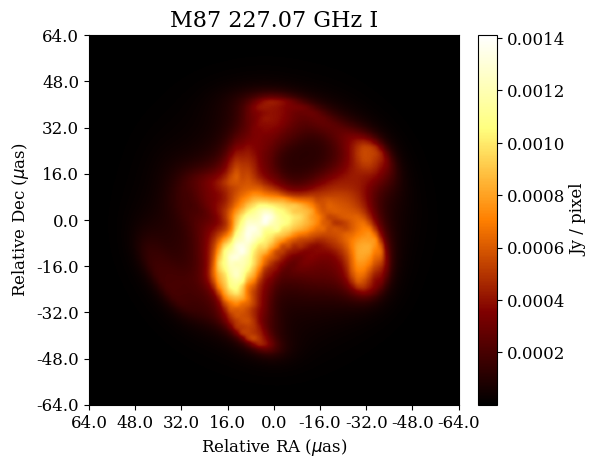

In [63]:
# imaging with a smaller Gaussian blob for the initialization.
gauss_fwhm_small = 40 *Pyehtim.ehtim.RADPERUAS
emptyim = Pyehtim.ehtim.image.make_square(obs_M87_orig, npix, fov)
gaussim_small = emptyim.add_gauss(
    zbl, (gauss_fwhm_small, gauss_fwhm_small, 0, 0, 0))
gaussim_small = gaussim_small.add_gauss(
    zbl * 1e-3, (gauss_fwhm_small, gauss_fwhm_small, 0,
                 gauss_fwhm_small, gauss_fwhm_small))
gaussim_small.display()
     

# Set up imager.
imgr = Pyehtim.ehtim.imager.Imager(
  obs_M87_scan_avg,
  init_im=gaussim_small,
  prior_im=gaussim_small,
  flux=zbl,
  data_term=data_term,
  reg_term=reg_term,
  norm_reg=true,
  systematic_noise=systematic_noise,
  maxit=100,
  ttype="fast")

# Run one round of imaging.
imgr.make_image_I(show_updates=true)

# Show the result of imaging.
out = imgr.out_last()
out.display();
     


In [64]:
plt.savefig("Gauss_40_real")

Python: None

In [65]:
# imaging with a smaller Gaussian blob for the initialization.
gauss_fwhm_small = 50 *Pyehtim.ehtim.RADPERUAS
emptyim = Pyehtim.ehtim.image.make_square(obs_M87_orig, npix, fov)
gaussim_small = emptyim.add_gauss(
    zbl, (gauss_fwhm_small, gauss_fwhm_small, 0, 0, 0))
gaussim_small = gaussim_small.add_gauss(
    zbl * 1e-3, (gauss_fwhm_small, gauss_fwhm_small, 0,
                 gauss_fwhm_small, gauss_fwhm_small))
gaussim_small.display()
     

# Set up imager.
imgr = Pyehtim.ehtim.imager.Imager(
  obs_M87_scan_avg,
  init_im=gaussim_small,
  prior_im=gaussim_small,
  flux=zbl,
  data_term=data_term,
  reg_term=reg_term,
  norm_reg=true,
  systematic_noise=systematic_noise,
  maxit=100,
  ttype="fast")

# Run one round of imaging.
imgr.make_image_I(show_updates=true)

# Show the result of imaging.
out = imgr.out_last()
out.display();
 plt.savefig("Gauss_50_real")    


------------------------------------------------------------------
  81 | chi2_amp : 30.36 chi2_cphase : 6.73 chi2_logcamp : 6.72 
        amp : 6.1 cphase : 6.7 logcamp : 6.7 
        flux : 0.5 simple : 25.9 tv : 3.4 tv2 : 2.1 
------------------------------------------------------------------
  82 | chi2_amp : 30.44 chi2_cphase : 6.73 chi2_logcamp : 7.18 
        amp : 6.1 cphase : 6.7 logcamp : 7.2 
        flux : 0.7 simple : 25.2 tv : 3.4 tv2 : 2.0 
------------------------------------------------------------------
  83 | chi2_amp : 30.21 chi2_cphase : 6.90 chi2_logcamp : 7.53 
        amp : 6.0 cphase : 6.9 logcamp : 7.5 
        flux : 1.0 simple : 24.6 tv : 3.3 tv2 : 1.9 
------------------------------------------------------------------
  84 | chi2_amp : 29.47 chi2_cphase : 6.86 chi2_logcamp : 7.49 
        amp : 5.9 cphase : 6.9 logcamp : 7.5 
        flux : 0.9 simple : 24.7 tv : 3.3 tv2 : 1.9 
------------------------------------------------------------------
  85 | chi2_a

Python: None

In [66]:
# imaging with a smaller Gaussian blob for the initialization.
gauss_fwhm_small = 60 *Pyehtim.ehtim.RADPERUAS
emptyim = Pyehtim.ehtim.image.make_square(obs_M87_orig, npix, fov)
gaussim_small = emptyim.add_gauss(
    zbl, (gauss_fwhm_small, gauss_fwhm_small, 0, 0, 0))
gaussim_small = gaussim_small.add_gauss(
    zbl * 1e-3, (gauss_fwhm_small, gauss_fwhm_small, 0,
                 gauss_fwhm_small, gauss_fwhm_small))
gaussim_small.display()
     

# Set up imager.
imgr = Pyehtim.ehtim.imager.Imager(
  obs_M87_scan_avg,
  init_im=gaussim_small,
  prior_im=gaussim_small,
  flux=zbl,
  data_term=data_term,
  reg_term=reg_term,
  norm_reg=true,
  systematic_noise=systematic_noise,
  maxit=100,
  ttype="fast")

# Run one round of imaging.
imgr.make_image_I(show_updates=true)

# Show the result of imaging.
out = imgr.out_last()
out.display();
 plt.savefig("Gauss_60_real")    


------------------------------------------------------------------
  82 | chi2_amp : 22.20 chi2_cphase : 13.11 chi2_logcamp : 6.09 
        amp : 4.4 cphase : 13.1 logcamp : 6.1 
        flux : 0.2 simple : 14.2 tv : 2.5 tv2 : 0.9 
------------------------------------------------------------------
  83 | chi2_amp : 21.30 chi2_cphase : 12.90 chi2_logcamp : 5.86 
        amp : 4.3 cphase : 12.9 logcamp : 5.9 
        flux : 0.2 simple : 14.4 tv : 2.5 tv2 : 0.9 
------------------------------------------------------------------
  84 | chi2_amp : 19.95 chi2_cphase : 12.25 chi2_logcamp : 5.42 
        amp : 4.0 cphase : 12.3 logcamp : 5.4 
        flux : 0.2 simple : 14.9 tv : 2.6 tv2 : 0.9 
------------------------------------------------------------------
  85 | chi2_amp : 18.90 chi2_cphase : 11.63 chi2_logcamp : 5.45 
        amp : 3.8 cphase : 11.6 logcamp : 5.4 
        flux : 0.2 simple : 15.2 tv : 2.6 tv2 : 1.0 
------------------------------------------------------------------
  86 

Python: None